## covering factor

### calcolo dei covering factor

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Costanti fisiche in cgs
c = 2.99792458e10
G = 6.67430e-8
h = 6.62607015e-27
kB = 1.380649e-16
sigma = 5.670374419e-5 #costante di Stefan-Boltzmann
Msun = 1.98847e33

# Parametri del modello
eta = 0.083
Nr = 2000
Nnu = 400
nu_min = 1e13
nu_max = 1e17

# File input
file_linee = "Tab_completa_revisione.csv"
file_transizioni = "dati.asc"

In [54]:
# Casi possibili per MBH e lambda_edd
SCENARI = [
    {"scenario": "MBH_5e8_lambda_0.01", "MBH_solar": 5e8, "lambda_edd": 0.01},
    {"scenario": "MBH_5e8_lambda_0.1",  "MBH_solar": 5e8, "lambda_edd": 0.1},
    {"scenario": "MBH_1e9_lambda_0.01", "MBH_solar": 1e9, "lambda_edd": 0.01},
    {"scenario": "MBH_1e9_lambda_0.1",  "MBH_solar": 1e9, "lambda_edd": 0.1},]

In [55]:
# funzione per trovare la colonna in un DataFrame dato un elenco di possibili nomi
def trova_colonna(df, possibili_nomi, obbligatoria=True):
    for nome in possibili_nomi:
        if nome in df.columns:
            return nome
    if obbligatoria:
        raise ValueError(f"Non trovo nessuna di queste colonne: {possibili_nomi}")
    return None

In [56]:
# funzione per costruire lo spettro del disco dal modello di Shakura-Sunyaev
#def costruisci_spettro_disco(MBH_solar, eta=0.083, lambda_edd=0.1, Nr=2000, Nnu=400, nu_min=1e13, nu_max=1e17):
def costruisci_spettro_disco(MBH_solar, lambda_edd, eta=0.083, Nr=2000, Nnu=400, nu_min=1e13, nu_max=1e17):
    """
    Costruisce lo spettro del disco per una massa MBH_solar [Msun] e un rapporto di Eddington lambda_edd.
    Restituisce nu, Lnu, nuLnu e un dizionario con i parametri fisici principali.
    """
    MBH = MBH_solar * Msun
    Ledd = 1.3e38 * MBH_solar
    Ldisk = lambda_edd * Ledd
    Mdot = Ldisk / (eta * c**2)

    Rs = 2 * G * MBH / c**2
    Rin = 3 * Rs
    Rout = 3000 * Rs
    R = np.logspace(np.log10(Rin), np.log10(Rout), Nr)

    f = 1.0 - np.sqrt(Rin / R)
    f = np.clip(f, 0.0, None)
    T = ((3 * G * MBH * Mdot) / (8 * np.pi * sigma * R**3) * f)**0.25

    nu = np.logspace(np.log10(nu_min), np.log10(nu_max), Nnu)

    Bnu = np.zeros((Nnu, Nr))
    for j in range(Nr):
        if T[j] <= 0:
            continue
        x = h * nu / (kB * T[j])
        x = np.clip(x, 1e-12, 700.0)
        Bnu[:, j] = (2 * h * nu**3 / c**2) / (np.exp(x) - 1.0)

    integrand = R[None, :] * Bnu
    I_nu = np.trapezoid(integrand, R, axis=1)
    Lnu = 4 * np.pi**2 * I_nu
    nuLnu = nu * Lnu

    info = { "MBH_solar": MBH_solar, "Ledd": Ledd, "Ldisk": Ldisk, "Mdot": Mdot, "Rs": Rs, "Rin": Rin, "Rout": Rout}
    return nu, Lnu, nuLnu, info

In [57]:
# funzione per leggere il file delle transizioni
def leggi_transizioni(file_transizioni):
    """
    Legge dati.asc con 3 colonne:
    nome_transizione   E_ion   nu_ion
    """
    names, Eion, nu_ion_list = np.genfromtxt(
        file_transizioni,
        dtype=('U50', float, float),
        unpack=True)

    return pd.DataFrame({
        "line_name": names,
        "E_ion": Eion,
        "nu_ion": nu_ion_list})

In [58]:
# funzione per calcolare L_ion per ogni transizione
def calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=1e17):
    """
    Calcola L_ion = integral_{nu_ion}^{nu_max} Lnu dnu per ogni transizione.
    """
    risultati = []

    for _, row in df_trans.iterrows():
        line_name = row["line_name"]
        E_ion = row["E_ion"]
        nu_ion = row["nu_ion"]
        if nu_ion >= nu_max:
            L_ion = 0.0
        else:
            mask = (nu >= nu_ion) & (nu <= nu_max)
            if np.sum(mask) < 2:
                L_ion = 0.0
            else:
                L_ion = np.trapezoid(Lnu[mask], nu[mask])

        risultati.append({
            "line_name": line_name,
            "E_ion": E_ion,
            "nu_ion": nu_ion,
            "L_ion": L_ion})

    return pd.DataFrame(risultati)

In [59]:
# funzione per estrarre le linee osservate positive da una riga del dataframe
def estrai_linee_osservate(row, norm_columns):
    """
    Estrae le linee osservate positive da una riga del dataframe.
    """
    risultati = []

    for col in norm_columns:
        valore = row[col]
        if pd.isna(valore) or valore <= 0:
            continue

        line_name = col.replace("_norm", "")
        L_line = valore * 1e42

        risultati.append({
            "line_name": line_name,
            "norm_value": valore,
            "L_line": L_line})

    return pd.DataFrame(risultati)

In [60]:
# funzione per fare il grafico dello spettro con le linee di ionizzazione
def fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar, scenario_name):
    plt.figure(figsize=(8, 6))
    plt.loglog(nu, Lnu, color="black", lw=2, label="Lnu disco")

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % cmap.N) for i in range(len(df_lion))]

    for (_, row), col in zip(df_lion.iterrows(), colors):
        plt.axvline(row["nu_ion"], color=col, lw=1.4, alpha=0.8, label=row["line_name"])

    plt.xlabel("nu [Hz]")
    plt.ylabel("Lnu [erg s^-1 Hz^-1]")
    plt.title(f"Spettro del disco - {nome_blazar} - {scenario_name}")
    plt.xlim(nu.min(), nu.max())
    #limite su y da 10^17 fino a 10^30
    plt.ylim(1e17, 1e30)
    plt.legend(fontsize=8, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

In [61]:
# Lettura dei file e preparazione dei dati
df_tab = pd.read_csv(file_linee)
df_trans = leggi_transizioni(file_transizioni)
#print("Colonne in Tab_completa_revisione.csv:")
#print(df_tab.columns.tolist())

#print("\nPrime transizioni lette da dati.asc:")
#display(df_trans.head())

# Identificazione delle colonne utili
col_name_tab = trova_colonna(df_tab, ["label", "file_name", "name", "nome", "blazar"])
norm_columns = [col for col in df_tab.columns if col.endswith("_norm")]

#print("Colonna nome in tabella linee:", col_name_tab)
#print("Colonne di linea trovate:")
#print(norm_columns)

# Base dei dati: solo tabella linee
df_all = df_tab.rename(columns={col_name_tab: "label"}).copy()
#print(f"Blazar trovati: {len(df_all)}")
#display(df_all[["label"]].head())

In [62]:
# ANALISI DI UN SINGOLO BLAZAR
def analizza_blazar(row, df_trans, norm_columns, mostra_grafico=True, verbose=True):
    nome_blazar = row["label"]
    MBH_solar = row["MBH_solar"]
    lambda_edd = row["lambda_edd"]
    scenario_name = row["scenario"]
    redshift = row["redshift"] if "redshift" in row.index else np.nan

    if verbose:
        print("=" * 80)
        print(f"Scenario = {scenario_name}")
        print(f"Blazar: {nome_blazar}")
        print(f"redshift = {redshift}")
        print(f"MBH = {MBH_solar:.3e} Msun")
        print(f"lambda_edd = {lambda_edd:.3f}")

    # spettro disco
    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=MBH_solar,
        eta=eta,
        lambda_edd=lambda_edd,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max)

    if verbose:
        print(f"Ledd  = {info['Ledd']:.3e} erg/s")
        print(f"Ldisk = {info['Ldisk']:.3e} erg/s")
        print(f"Mdot  = {info['Mdot']:.3e} g/s")

    # L_ion teoriche
    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)

    # linee osservate
    df_linee = estrai_linee_osservate(row, norm_columns)

    if verbose:
        print("\nLinee osservate del blazar:")
        display(df_linee)

    # merge e covering factor
    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[(df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0), "covering_factor"] = np.nan

    if verbose:
        print("\nConfronto finale per ogni linea:")
        display(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

    if mostra_grafico:
        fai_grafico_spettro(nu, Lnu, df_lion, nome_blazar, scenario_name)

    return df_conf


In [63]:
# Analisi di tutti i blazar in tutti e 4 gli scenari
tutti_risultati_scenari = []

for scenario in SCENARI:
    df_all_scenario = df_all.copy()
    df_all_scenario["MBH_solar"] = scenario["MBH_solar"]
    df_all_scenario["lambda_edd"] = scenario["lambda_edd"]
    df_all_scenario["scenario"] = scenario["scenario"]

    risultati_scenario = []

    for i in range(len(df_all_scenario)):
        row = df_all_scenario.iloc[i]
        df_conf = analizza_blazar(
            row,
            df_trans,
            norm_columns,
            mostra_grafico=False,
            verbose=False
        )

        df_conf["label"] = row["label"]
        df_conf["scenario"] = scenario["scenario"]
        df_conf["MBH_solar"] = scenario["MBH_solar"]
        df_conf["lambda_edd"] = scenario["lambda_edd"]
        risultati_scenario.append(df_conf)

    df_risultati_scenario = pd.concat(risultati_scenario, ignore_index=True)
    tutti_risultati_scenari.append(df_risultati_scenario)



In [64]:
# Creo un unico dataframe con i risultati di tutti i 4 scenari
df_risultati_finali = pd.concat(tutti_risultati_scenari, ignore_index=True) 

In [65]:
# 1) TABELLE PER BLAZAR
# Per ogni blazar costruisco una tabella con i 4 scenari sulle righe e le linee nelle colonne
tabelle_per_blazar = {} # dizionario per raccogliere le tabelle per ogni blazar (chiave = nome blazar, valore = tabella)
blazar_unici = sorted(df_risultati_finali["label"].unique())  # lista dei blazar, ordinati alfabeticamente

for blazar in blazar_unici:  # ciclo su ogni blazar 
    df_blazar = df_risultati_finali[df_risultati_finali["label"] == blazar].copy() # creo un dataframe con tutti i risultati di questo blazar
    tabella_blazar = df_blazar.pivot( # creo la tabella per questo blazar che contiene i 4 scenari sulle righe e le linee nelle colonne, con i valori del covering factor
        index="scenario",
        columns="line_name",
        values="covering_factor")
    #tabella_blazar = tabella_blazar.reindex(sorted(tabella_blazar.columns), axis=1) # ordino le colonne in ordine alfabetico
    #tabella_blazar = tabella_blazar.reset_index() # resetto l'indice per avere la colonna "scenario" come colonna normale
    #tabella_blazar = tabella_blazar.fillna("-") # sostituisco i valori NaN con "-" per indicare che non è possibile calcolare il covering factor (perché L_ion è zero o negativo)
    #tabelle_per_blazar[blazar] = tabella_blazar # aggiungo la tabella di questo blazar al dizionario delle tabelle per blazar
    tabella_blazar = tabella_blazar.reindex(sorted(tabella_blazar.columns), axis=1)  # ordino le colonne delle linee in ordine alfabetico
    tabella_blazar = tabella_blazar.reset_index()  # riporto "scenario" da indice a colonna normale 
    ordine_scenari = [s["scenario"] for s in SCENARI]  # uso l'ordine fisico definito all'inizio
    tabella_blazar = tabella_blazar.set_index("scenario").loc[ordine_scenari].reset_index()
    tabella_blazar = tabella_blazar.fillna("-")  # sostituisco i NaN con "-"
    tabelle_per_blazar[blazar] = tabella_blazar  # salvo la tabella nel dizionario

print(f"Tabelle create per blazar: {len(tabelle_per_blazar)}") # dovrebbe essere uguale al numero di blazar (13)
# Visualizzazione delle 13 tabelle 
for blazar, tabella in tabelle_per_blazar.items(): # ciclo su ogni blazar e tabella corrispondente
    print("\n" + "=" * 100) 
    print(f"Blazar: {blazar}")
    display(tabella) 

# Salvataggio di tutte le tabelle in un unico file CSV
with open("Cf_tabelle_blazar.csv", "w") as f:
    for blazar, tabella in tabelle_per_blazar.items():
        f.write("=" * 80 + "\n")
        f.write(f"Blazar: {blazar}\n")
        f.write("=" * 80 + "\n")
        tabella.to_csv(f, index=False)
        f.write("\n\n")

Tabelle create per blazar: 13

Blazar: J0021.6-6835


line_name,scenario,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.013738,0.003057,0.004108
1,MBH_5e8_lambda_0.1,0.001166,0.000248,0.000340
2,MBH_1e9_lambda_0.01,0.007432,0.001690,0.002251
3,MBH_1e9_lambda_0.1,0.000605,0.000130,0.000177



Blazar: J0050.0-4458


line_name,scenario,Ha,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.000631,0.000140,2.286435e-05,0.000121
1,MBH_5e8_lambda_0.1,0.000056,0.000012,1.856134e-06,0.000010
2,MBH_1e9_lambda_0.01,0.000333,0.000076,1.263839e-05,0.000066
3,MBH_1e9_lambda_0.1,0.000029,0.000006,9.729825e-07,0.000005



Blazar: J0059.1-5701


...

line_name,scenario,Ha,Hb
0,MBH_5e8_lambda_0.01,0.006869,0.002307
1,MBH_5e8_lambda_0.1,0.000615,0.000196
2,MBH_1e9_lambda_0.01,0.003622,0.001248
3,MBH_1e9_lambda_0.1,0.000315,0.000102



Blazar: J1816.9-4944


line_name,scenario,CIII,CIV,MgII
0,MBH_5e8_lambda_0.01,2.196560e+06,1.054538e+05,0.175092
1,MBH_5e8_lambda_0.1,6.126595e+01,9.700866e+00,0.003194
2,MBH_1e9_lambda_0.01,4.366994e+07,1.245472e+06,0.197138
3,MBH_1e9_lambda_0.1,2.108012e+02,2.503617e+01,0.002348



Blazar: J2237.5-8326


line_name,scenario,Hb,Hd,Hg
0,MBH_5e8_lambda_0.01,0.015212,0.000258,0.005426
1,MBH_5e8_lambda_0.1,0.001291,0.000021,0.000449
2,MBH_1e9_lambda_0.01,0.008229,0.000143,0.002973
3,MBH_1e9_lambda_0.1,0.000670,0.000011,0.000234


In [66]:
# 2) TABELLE PER SCENARIO
# Per ogni scenario costruisco una tabella con i 13 blazar sulle righe e le linee nelle colonne
tabelle_per_scenario = {}
scenari_unici = [s["scenario"] for s in SCENARI]

for scenario in scenari_unici:
    df_scenario = df_risultati_finali[df_risultati_finali["scenario"] == scenario].copy()
    tabella_scenario = df_scenario.pivot(
        index="label",
        columns="line_name",
        values="covering_factor")
    # ordino le colonne (linee)
    tabella_scenario = tabella_scenario.reindex(sorted(tabella_scenario.columns), axis=1)
    tabella_scenario = tabella_scenario.reset_index()
    tabella_scenario = tabella_scenario.fillna("-")
    tabelle_per_scenario[scenario] = tabella_scenario

# Visualizzazione delle 4 tabelle (nell'ordine giusto)
for scenario in scenari_unici:
    print("\n" + "=" * 100)
    print(f"Scenario: {scenario}")
    display(tabelle_per_scenario[scenario])


Scenario: MBH_5e8_lambda_0.01


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.013738,0.003057,0.004108,-
1,J0050.0-4458,-,-,0.000631,0.00014,0.000023,0.000121,-
2,J0059.1-5701,-,-,-,-,0.043824,0.094628,2.002049
3,J0133.2-5159,-,-,-,-,0.041624,-,2.696624
4,J0508.2-1936,1193411.124051,594212.001571,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.044809,0.064434,0.024008,7.499409
6,J1123.3-2529,-,-,0.004104,0.00882,0.001304,0.003724,-
7,J1329.4-0530,-,-,-,-,0.094669,0.026786,2.058971
8,J152422.56,1181.124332,-,-,-,0.000503,-,0.005954
9,J170108.89,8249.406622,140.628256,-,-,-,-,0.007975



Scenario: MBH_5e8_lambda_0.1


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.001166,0.000248,0.00034,-
1,J0050.0-4458,-,-,0.000056,0.000012,0.000002,0.00001,-
2,J0059.1-5701,-,-,-,-,0.003558,0.007822,0.03652
3,J0133.2-5159,-,-,-,-,0.003379,-,0.04919
4,J0508.2-1936,33.286344,54.662549,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.003804,0.005231,0.001984,0.136799
6,J1123.3-2529,-,-,0.000367,0.000749,0.000106,0.000308,-
7,J1329.4-0530,-,-,-,-,0.007685,0.002214,0.037558
8,J152422.56,0.032944,-,-,-,0.000041,-,0.000109
9,J170108.89,0.230091,0.012937,-,-,-,-,0.000145



Scenario: MBH_1e9_lambda_0.01


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.007432,0.00169,0.002251,-
1,J0050.0-4458,-,-,0.000333,0.000076,0.000013,0.000066,-
2,J0059.1-5701,-,-,-,-,0.024224,0.051852,2.254128
3,J0133.2-5159,-,-,-,-,0.023008,-,3.036157
4,J0508.2-1936,23726274.526622,7017997.100168,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.024239,0.035616,0.013156,8.443663
6,J1123.3-2529,-,-,0.002164,0.004771,0.000721,0.002041,-
7,J1329.4-0530,-,-,-,-,0.052329,0.014678,2.318217
8,J152422.56,23482.000119,-,-,-,0.000278,-,0.006704
9,J170108.89,164006.922895,1660.903332,-,-,-,-,0.00898



Scenario: MBH_1e9_lambda_0.1


line_name,label,CIII,CIV,Ha,Hb,Hd,Hg,MgII
0,J0021.6-6835,-,-,-,0.000605,0.00013,0.000177,-
1,J0050.0-4458,-,-,0.000029,0.000006,0.000001,0.000005,-
2,J0059.1-5701,-,-,-,-,0.001865,0.004083,0.02685
3,J0133.2-5159,-,-,-,-,0.001771,-,0.036166
4,J0508.2-1936,114.5302,141.074081,-,-,-,-,-
5,J0922.8-3959,-,-,-,0.001974,0.002742,0.001036,0.100578
6,J1123.3-2529,-,-,0.000188,0.000389,0.000055,0.000161,-
7,J1329.4-0530,-,-,-,-,0.004029,0.001156,0.027614
8,J152422.56,0.113351,-,-,-,0.000021,-,0.00008
9,J170108.89,0.791685,0.033387,-,-,-,-,0.000107


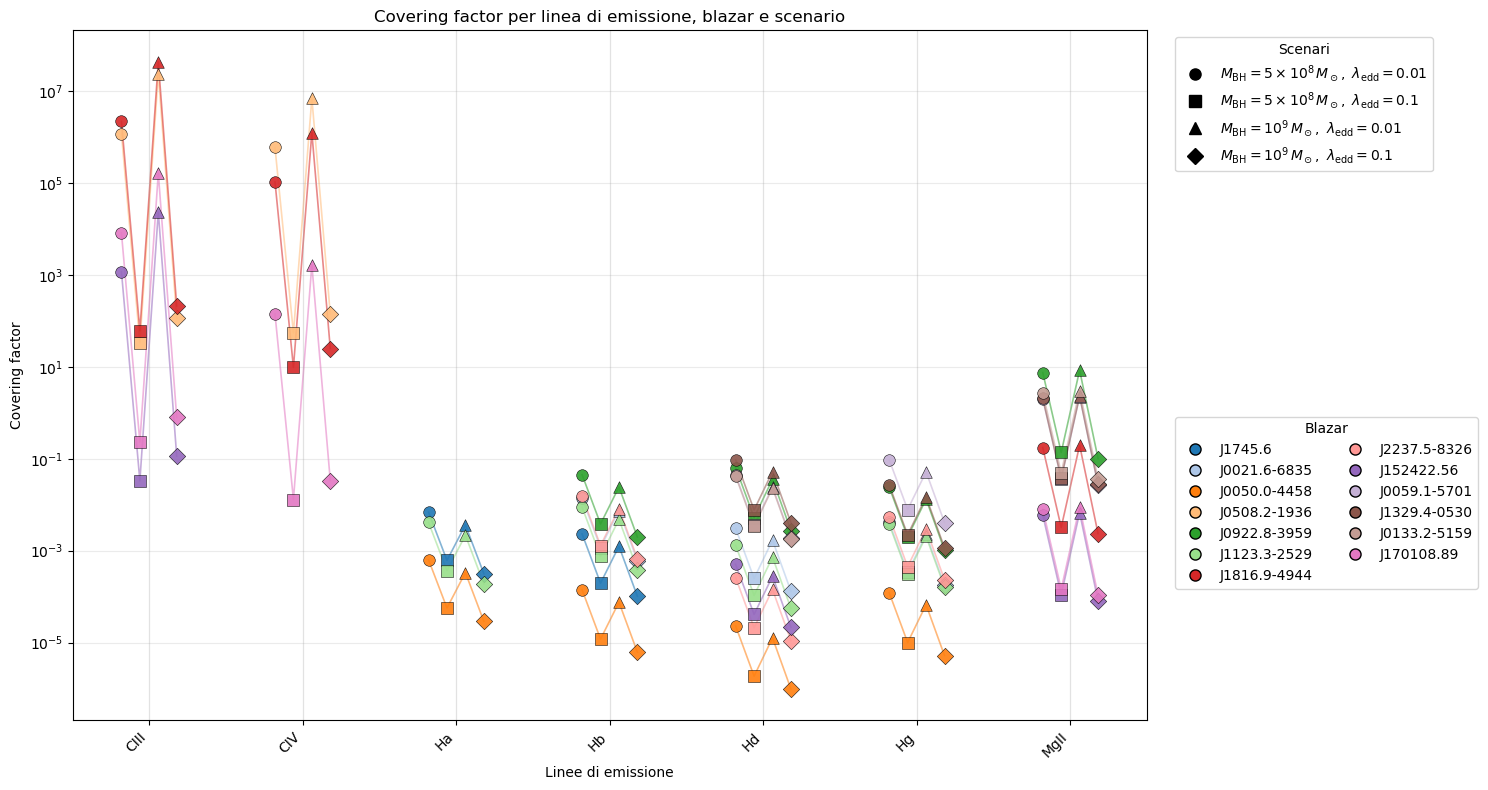

In [67]:
from matplotlib.lines import Line2D

df_plot = df_risultati_finali.copy()
# Tengo solo covering factor validi
df_plot = df_plot[df_plot["covering_factor"].notna()].copy()
df_plot = df_plot[df_plot["covering_factor"] > 0].copy()

# Ordine delle linee
ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_plot["line_name"].dropna().unique().tolist()
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

# Ordine originale dei blazar
ordine_blazar = df_all["label"].drop_duplicates().tolist()

# Posizione centrale di ogni linea sull'asse x
x_map = {linea: i for i, linea in enumerate(linee_uniche)}  # mappa che associa a ogni linea un numero intero crescente (0, 1, 2, ...) in base all'ordine delle linee
df_plot["x_base"] = df_plot["line_name"].map(x_map)  # creo una nuova colonna "x_base" che contiene la posizione centrale di ogni linea sull'asse x, mappando il nome della linea alla sua posizione tramite x_map

# Ordine e offset degli scenari per evitare sovrapposizioni dei punti sulla riga di emissione
ordine_scenari = [s["scenario"] for s in SCENARI]
offset_scenario = {
    "MBH_5e8_lambda_0.01": -0.18,
    "MBH_5e8_lambda_0.1":  -0.06,
    "MBH_1e9_lambda_0.01":  0.06,
    "MBH_1e9_lambda_0.1":   0.18,
}

df_plot["scenario"] = pd.Categorical( # creo una colonna "scenario" come categoria ordinata per mantenere l'ordine definito in SCENARI
    df_plot["scenario"], # prendo la colonna "scenario" dal dataframe
    categories=ordine_scenari, # uso l'ordine fisico definito all'inizio
    ordered=True # ordina le categorie in base all'ordine fisico
)
df_plot["x"] = df_plot["x_base"] + df_plot["scenario"].map(offset_scenario).astype(float)  # creo una nuova colonna "x" che contiene la posizione finale di ogni punto sull'asse x, sommando la posizione centrale della linea (x_base) con l'offset specifico per lo scenario (mappato tramite offset_scenario)

# Colori e marker per blazar e scenario
cmap = plt.get_cmap("tab20")  # uso una colormap con molti colori per distinguere i blazar
color_map = {blazar: cmap(i) for i, blazar in enumerate(ordine_blazar)}  # mappa che associa a ogni blazar un colore da cmap
marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

fig, ax = plt.subplots(figsize=(15, 8)) 

for blazar in ordine_blazar:  # ciclo su ogni blazar
    df_bl = df_plot[df_plot["label"] == blazar].copy()  #df_bl= creo un dataframe con tutti i risultati di questo blazar, df_plot= dataframe con tutti i risultati di tutti i blazar
    if df_bl.empty:  # se non ci sono dati per questo blazar, salto al prossimo
        continue
    # Collego i punti dei diversi scenari della stessa riga di emissione dello stesso blazar con una linea leggera dello stesso colore del blazar
    for linea in linee_uniche:  # ciclo su ogni linea nell'ordine definito da linee_uniche
        grp_linea = df_bl[df_bl["line_name"] == linea].sort_values("scenario").copy()  # creo un gruppo di dati per questa linea, ordinato per scenario
        if len(grp_linea) < 2: # non posso collegare meno di 2 punti
            continue
        ax.plot(  # disegno la linea 
            grp_linea["x"], # prendo la colonna "x" che contiene la posizione finale di ogni punto sull'asse x
            grp_linea["covering_factor"],  # prendo la colonna "covering_factor" che contiene il valore del covering factor per ogni punto
            color=color_map[blazar], # assegno il colore del blazar
            linewidth=1.2,
            alpha=0.55,
            zorder=1
        )

    # Disegno i punti scenario per scenario
    for scenario in ordine_scenari: 
        grp = df_bl[df_bl["scenario"] == scenario].copy() # creo un gruppo di dati per questo scenario
        if grp.empty:
            continue
        ax.scatter( # disegno i punti
            grp["x"], 
            grp["covering_factor"],
            color=color_map[blazar],
            marker=marker_map[scenario],
            s=70,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.4,
            zorder=2
        )

ax.set_xticks(range(len(linee_uniche)))# imposto i tick dell'asse x in corrispondenza di ogni linea, usando la posizione centrale di ogni linea (0, 1, 2, ...) definita in x_map
ax.set_xticklabels(linee_uniche, rotation=45, ha="right")
ax.set_yscale("log") # imposto scala logaritmica per l'asse y per meglio visualizzare i valori di covering factor che possono variare su più ordini di grandezza
ax.set_xlabel("Linee di emissione")
ax.set_ylabel("Covering factor")
ax.set_title("Covering factor per linea di emissione, blazar e scenario")
ax.grid(True, which="both", alpha=0.25)

for i in range(len(linee_uniche)):  # righe per evidenziare le linee di emissione con linee verticali leggere
    ax.axvline(i, color="gray", alpha=0.08, lw=1)

legend_scenari = [
    Line2D([0], [0], marker="o", color="black", linestyle="None",
           markersize=8, label=r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \lambda_{\rm edd}=0.01$"),
    Line2D([0], [0], marker="s", color="black", linestyle="None",
           markersize=8, label=r"$M_{\rm BH}=5\times10^8\,M_\odot,\ \lambda_{\rm edd}=0.1$"),
    Line2D([0], [0], marker="^", color="black", linestyle="None",
           markersize=8, label=r"$M_{\rm BH}=10^9\,M_\odot,\ \lambda_{\rm edd}=0.01$"),
    Line2D([0], [0], marker="D", color="black", linestyle="None",
           markersize=8, label=r"$M_{\rm BH}=10^9\,M_\odot,\ \lambda_{\rm edd}=0.1$"),
]

leg1 = ax.legend(  # metto la legenda per gli scenari, con i marker e le etichette corrispondenti, posizionata a destra fuori dal grafico
    handles=legend_scenari,
    title="Scenari",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=True
)

legend_blazar = [  
    Line2D([0], [0], marker="o", color="w",
           markerfacecolor=color_map[blazar],
           markeredgecolor="black",
           markersize=8,
           label=blazar)
    for blazar in ordine_blazar
]

leg2 = ax.legend(  # metto la legenda per i blazar, con i marker e le etichette corrispondenti, posizionata a destra sotto la legenda degli scenari
    handles=legend_blazar,
    title="Blazar",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.45),
    frameon=True,
    ncol=2
)

ax.add_artist(leg1)  # matplotlib permette di avere più legende, ma bisogna aggiungere la prima al grafico dopo aver creato la seconda per evitare che venga sovrascritta
plt.tight_layout()
plt.show()


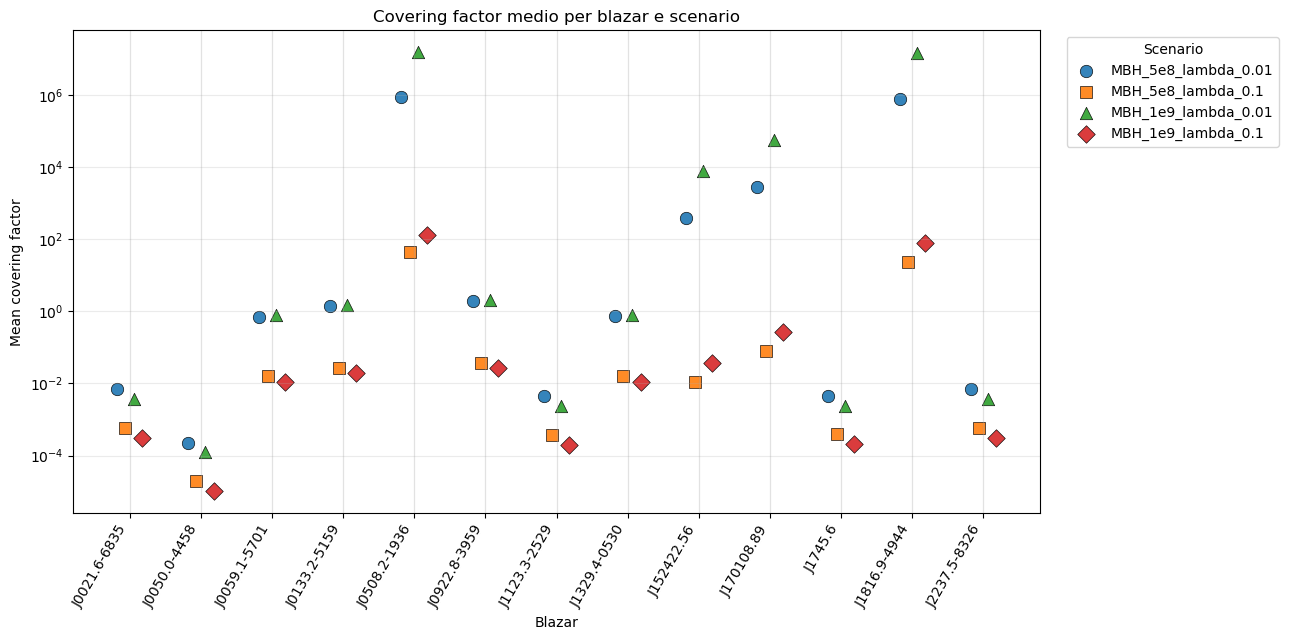

In [68]:
# =========================
# Grafico del covering factor medio per blazar e scenario
# =========================

df_cf_plot = df_risultati_finali.copy() # parto dal fìdataframe con tutti i risultati di tutti i blazar e scenari già calcolati

df_cf_plot["covering_factor"] = pd.to_numeric(df_cf_plot["covering_factor"], errors="coerce") 

df_cf_plot = df_cf_plot[  # tengo solo i valori di covering factor validi (non NaN e > 0)
    df_cf_plot["covering_factor"].notna() &
    (df_cf_plot["covering_factor"] > 0)
].copy()

# media del covering factor per blazar e scenario
df_cf_mean = (  # creo un nuovo dataframe df_cf_mean che contiene la media del covering factor per ogni combinazione di blazar, scenario
    df_cf_plot
    .groupby(["label", "scenario", "MBH_solar", "lambda_edd"], as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),  #calcolo la media del covering factor per ogni gruppo di blazar e scenario  CON MEAN
        Cf_std=("covering_factor", "std"),  #calcolo la deviazione standard del covering factor per ogni gruppo di blazar e scenario  CON STD
        N_linee=("covering_factor", "count")  #conto il numero di linee valide per ogni gruppo di blazar e scenario 
    )
)

ordine_scenari = [s["scenario"] for s in SCENARI]
blazar_unici = df_cf_mean["label"].drop_duplicates().tolist()

# posizione x dei blazar
x_map = {blazar: i for i, blazar in enumerate(blazar_unici)}

# offset per separare i 4 scenari
offset_map = {
    "MBH_5e8_lambda_0.01": -0.18,
    "MBH_5e8_lambda_0.1":  -0.06,
    "MBH_1e9_lambda_0.01":  0.06,
    "MBH_1e9_lambda_0.1":   0.18,
}

# marker per scenario
marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

# colori per scenario
color_map = {
    "MBH_5e8_lambda_0.01": "tab:blue",
    "MBH_5e8_lambda_0.1":  "tab:orange",
    "MBH_1e9_lambda_0.01": "tab:green",
    "MBH_1e9_lambda_0.1":  "tab:red",
}

df_cf_mean["x_base"] = df_cf_mean["label"].map(x_map)
df_cf_mean["x"] = df_cf_mean["x_base"] + df_cf_mean["scenario"].map(offset_map)

fig, ax = plt.subplots(figsize=(13, 6.5))

# punti
for scenario in ordine_scenari:
    df_s = df_cf_mean[df_cf_mean["scenario"] == scenario].copy()

    if df_s.empty:
        continue

    ax.scatter(
        df_s["x"],
        df_s["Cf_mean"],
        color=color_map[scenario],
        marker=marker_map[scenario],
        s=80,
        edgecolors="black",
        linewidths=0.5,
        alpha=0.9,
        label=scenario
    )

# linee verticali leggere per separare i blazar
for i in range(len(blazar_unici)):
    ax.axvline(i, color="gray", alpha=0.08, lw=1)

ax.set_xticks(range(len(blazar_unici)))
ax.set_xticklabels(blazar_unici, rotation=60, ha="right")

ax.set_yscale("log")
ax.set_xlabel("Blazar")
ax.set_ylabel("Mean covering factor")
ax.set_title("Covering factor medio per blazar e scenario")
ax.grid(True, which="both", alpha=0.25)

ax.legend(title="Scenario", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

### controllo dei valori di cf grossi

In [69]:
# Controllo completo per J1816 in un unico step

nome_target = "J1816"
scenario_MBH = 5e8
scenario_lambda = 0.01

# 1. Seleziono il blazar
row = df_all[df_all["label"].str.contains(nome_target, na=False)].iloc[0]

print("=" * 80)
print("Blazar selezionato:")
print(row["label"])

# 2. Estraggo le linee osservate
df_linee = estrai_linee_osservate(row, norm_columns)

print("\nLinee osservate:")
print(df_linee)

print("\nNomi linee osservate:")
print(df_linee["line_name"].tolist())

print("\nLinee disponibili nel file transizioni:")
print(df_trans["line_name"].unique())

# 3. Costruisco lo spettro del disco per lo scenario scelto
nu, Lnu, nuLnu, info = costruisci_spettro_disco(
    MBH_solar=scenario_MBH,
    lambda_edd=scenario_lambda,
    eta=eta,
    Nr=Nr,
    Nnu=Nnu,
    nu_min=nu_min,
    nu_max=nu_max
)

print("\nParametri fisici dello scenario:")
print(f"MBH = {scenario_MBH:.3e} Msun")
print(f"lambda_edd = {scenario_lambda:.3f}")
print(f"Ledd  = {info['Ledd']:.3e} erg/s")
print(f"Ldisk = {info['Ldisk']:.3e} erg/s")
print(f"Mdot  = {info['Mdot']:.3e} g/s")

# 4. Calcolo L_ion per tutte le transizioni
df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)

print("\nTabella L_ion per tutte le transizioni:")
print(df_lion)

# 5. Tengo solo le linee osservate di J1816
df_conf = df_linee.merge(df_lion, on="line_name", how="left")

# 6. Calcolo covering factor
df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
df_conf.loc[
    (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
    "covering_factor"
] = np.nan

print("\nConfronto finale:")
print(df_conf[["line_name", "norm_value", "L_line", "E_ion", "nu_ion", "L_ion", "covering_factor"]])

# 7. Evidenzio eventuali problemi
print("\nControlli diagnostici:")
print("Linee con L_ion mancante:")
print(df_conf[df_conf["L_ion"].isna()][["line_name"]])

print("\nLinee con L_ion <= 0:")
print(df_conf[df_conf["L_ion"] <= 0][["line_name", "L_ion"]])

print("\nLinee con covering_factor > 1:")
print(df_conf[df_conf["covering_factor"] > 1][["line_name", "L_line", "L_ion", "covering_factor"]])
print("=" * 80)

Blazar selezionato:
J1816.9-4944

Linee osservate:
  line_name  norm_value        L_line
0      MgII    4.645071  4.645071e+42
1       CIV   74.076527  7.407653e+43
2      CIII  129.490400  1.294904e+44

Nomi linee osservate:
['MgII', 'CIV', 'CIII']

Linee disponibili nel file transizioni:
['Ha' 'Hb' 'Hg' 'Hd' 'MgII' 'CIII' 'CIV' 'Mg_pp']

Parametri fisici dello scenario:
MBH = 5.000e+08 Msun
lambda_edd = 0.010
Ledd  = 6.500e+46 erg/s
Ldisk = 6.500e+44 erg/s
Mdot  = 8.714e+24 g/s

Tabella L_ion per tutte le transizioni:
  line_name  E_ion        nu_ion         L_ion
0        Ha   1.89  4.600000e+14  5.287321e+44
1        Hb   2.55  6.200000e+14  4.781810e+44
2        Hg   2.86  6.910000e+14  4.546675e+44
3        Hd   3.02  7.370000e+14  4.394148e+44
4      MgII  15.00  3.630000e+15  2.652927e+43
5      CIII  54.40  1.315000e+16  5.895144e+37
6       CIV  47.90  1.158000e+16  7.024551e+38
7     Mg_pp  80.10  1.940000e+16  9.087924e+33

Confronto finale:
  line_name  norm_value        L

In [70]:
nome_target = "J1816"

row = df_all[df_all["label"].str.contains(nome_target, na=False)].iloc[0]
df_linee = estrai_linee_osservate(row, norm_columns)

print("=" * 100)
print(f"Blazar selezionato: {row['label']}")
print("\nLinee osservate:")
print(df_linee)

for scenario in SCENARI:
    print("\n" + "=" * 100)
    print(f"Scenario: {scenario['scenario']}")

    nu, Lnu, nuLnu, info = costruisci_spettro_disco(
        MBH_solar=scenario["MBH_solar"],
        lambda_edd=scenario["lambda_edd"],
        eta=eta,
        Nr=Nr,
        Nnu=Nnu,
        nu_min=nu_min,
        nu_max=nu_max
    )

    df_lion = calcola_lion_per_transizioni(nu, Lnu, df_trans, nu_max=nu_max)

    df_conf = df_linee.merge(df_lion, on="line_name", how="left")
    df_conf["covering_factor"] = df_conf["L_line"] / df_conf["L_ion"]
    df_conf.loc[
        (df_conf["L_ion"].isna()) | (df_conf["L_ion"] <= 0),
        "covering_factor"
    ] = np.nan

    print(df_conf[["line_name", "L_line", "L_ion", "covering_factor"]])

Blazar selezionato: J1816.9-4944

Linee osservate:
  line_name  norm_value        L_line
0      MgII    4.645071  4.645071e+42
1       CIV   74.076527  7.407653e+43
2      CIII  129.490400  1.294904e+44

Scenario: MBH_5e8_lambda_0.01
  line_name        L_line         L_ion  covering_factor
0      MgII  4.645071e+42  2.652927e+43     1.750923e-01
1       CIV  7.407653e+43  7.024551e+38     1.054538e+05
2      CIII  1.294904e+44  5.895144e+37     2.196560e+06

Scenario: MBH_5e8_lambda_0.1
  line_name        L_line         L_ion  covering_factor
0      MgII  4.645071e+42  1.454348e+45         0.003194
1       CIV  7.407653e+43  7.636073e+42         9.700866
2      CIII  1.294904e+44  2.113579e+42        61.265950

Scenario: MBH_1e9_lambda_0.01
  line_name        L_line         L_ion  covering_factor
0      MgII  4.645071e+42  2.356251e+43     1.971382e-01
1       CIV  7.407653e+43  5.947669e+37     1.245472e+06
2      CIII  1.294904e+44  2.965206e+36     4.366994e+07

Scenario: MBH_1e9_la

CONCLUDO: Ottengo valori così grandi del covering factor perché sto dividendo una luminosità osservata molto elevata per una luminosità ionizzante teorica estremamente piccola: nel mio modello il disco, soprattutto nei casi con massa alta e basso lambda_edd, è troppo freddo e non produce abbastanza fotoni alle alte frequenze necessarie a ionizzare linee come CIII e CIV, quindi L_ion crolla di molti ordini di grandezza mentre L_line resta alta (e in oggetti come J1816 è già molto grande nei dati), facendo esplodere il rapporto Cf = L_line / L_ion; di fatto questo non è un errore numerico, ma mi indica che il modello di disco puro non è sufficiente a spiegare quelle linee ad alta ionizzazione, oppure che i valori osservativi potrebbero essere sovrastimati o non completamente coerenti.

### test statistici per le proprietà del covering factor

#### Pearson con redshift

PEARSON TEST: Il coefficiente di Pearson misura quanto i punti si dispongono lungo una retta: se è vicino a 1 o -1 significa che c’è una correlazione lineare forte, mentre se è vicino a 0 non c’è una relazione lineare evidente. Tuttavia nel mio caso questo test ha dei limiti importanti, perché ho pochi oggetti, il covering factor varia su molti ordini di grandezza e la relazione potrebbe non essere lineare ma, ad esempio, monotona o logaritmica.

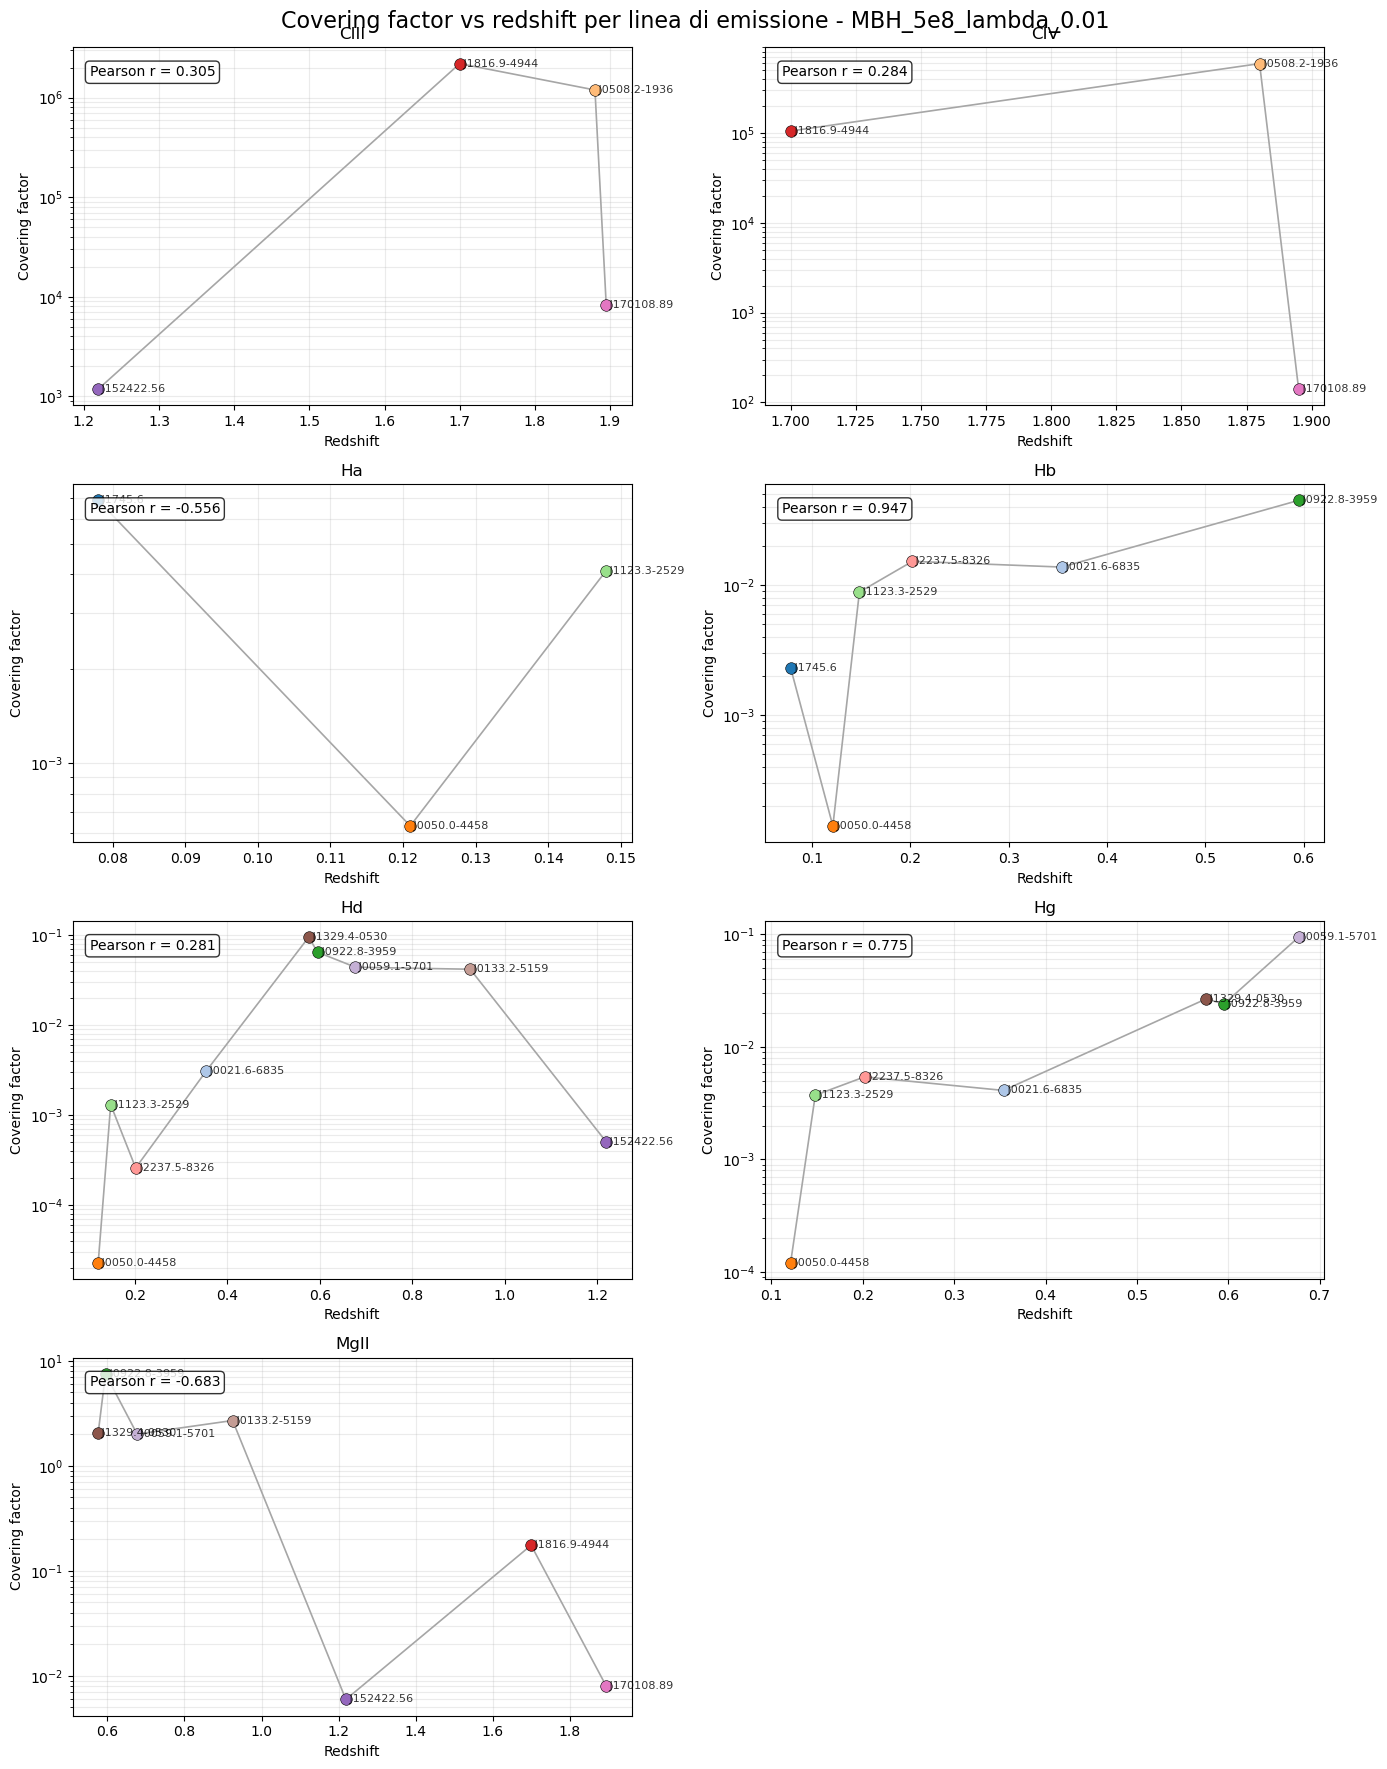

In [71]:
# Covering factor vs redshift per un singolo scenario
scenario_scelto = "MBH_5e8_lambda_0.01"

col_redshift = trova_colonna(   #trova la colonna del redshift nel dataframe
    df_all,  #dataframe in cui cercare la colonna
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_cf_z = df_risultati_finali.merge(  #faccio un merge tra il dataframe con i risultati finali e il dataframe originale df_all per aggiungere la colonna del redshift, usando la colonna "label" come chiave di unione
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_cf_z["redshift"] = pd.to_numeric(df_cf_z["redshift"], errors="coerce")  #"converto" la colonna del redshift in numeri
df_cf_z["covering_factor"] = pd.to_numeric(df_cf_z["covering_factor"], errors="coerce")

df_cf_z = df_cf_z[  #filtro per tenere solo i dati dello scenario scelto, con redshift e covering factor validi e > 0
    (df_cf_z["scenario"] == scenario_scelto) &
    (df_cf_z["redshift"].notna()) &
    (df_cf_z["covering_factor"].notna()) &
    (df_cf_z["covering_factor"] > 0)
].copy()

ordine_linee_preferito = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_cf_z["line_name"].dropna().unique().tolist()  #lista delle linee presenti nei dati filtrati, senza NaN e senza duplicati
linee_uniche = [l for l in ordine_linee_preferito if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]  

ordine_blazar = df_all["label"].drop_duplicates().tolist()  #ordine originale dei blazar
cmap = plt.get_cmap("tab20")  #colormap con molti colori per distinguere i blazar
color_map_blazar = {blazar: cmap(i) for i, blazar in enumerate(ordine_blazar)}

n_linee = len(linee_uniche)  
ncols = 2  #numero di colonne per i sottografici
nrows = int(np.ceil(n_linee / ncols)) #calcolo il numero di righe necessarie per avere un sottografico per ogni linea, con 2 colonne per riga, usando la funzione ceil per arrotondare all'intero superiore

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), sharex=False, sharey=False)
axes = np.array(axes).reshape(-1)  

for ax, linea in zip(axes, linee_uniche):  #creo 1 pannello per ogni riga di emissione, ciclano su ogni asse e linea in parallelo, usando zip per abbinare ogni asse alla sua linea corrispondente
    df_linea = df_cf_z[df_cf_z["line_name"] == linea].sort_values("redshift").copy()
    if df_linea.empty:
        ax.axis("off")
        continue
    ax.plot(  
        df_linea["redshift"],  #asse x = redshift
        df_linea["covering_factor"],  #asse y = covering factor
        color="gray",
        linewidth=1.2,
        alpha=0.7,
        zorder=1
    )
    for _, row in df_linea.iterrows():  #per ogni punto di questa linea, disegno un punto colorato in base al blazar e aggiungo l'etichetta del blazar accanto al punto
        ax.scatter(
            row["redshift"],
            row["covering_factor"],
            color=color_map_blazar[row["label"]],
            s=70,
            edgecolors="black",
            linewidths=0.4,
            zorder=2
        )
        ax.text(
            row["redshift"],
            row["covering_factor"],
            f" {row['label']}",
            fontsize=8,
            va="center",
            ha="left",
            alpha=0.8
        )

    if (  #controllo se è possibile calcolare il coefficiente di correlazione di Pearson tra redshift e covering factor per questa linea, verificando che ci siano almeno 2 punti e che ci sia variazione sia nel redshift che nel covering factor
        len(df_linea) >= 2 and
        df_linea["redshift"].nunique() > 1 and
        df_linea["covering_factor"].nunique() > 1
    ):
        pearson = df_linea["redshift"].corr(df_linea["covering_factor"], method="pearson") #calcolo il coefficiente di correlazione lineare di Pearson tra redshift e covering factor per questa linea usando la funzione corr di pandas, specificando method="pearson" per essere espliciti
    else:
        pearson = np.nan
    ax.text(
        0.03, 0.95,
        f"Pearson r = {pearson:.3f}" if pd.notna(pearson) else "Pearson r = nan",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    ax.set_title(linea)
    ax.set_xlabel("Redshift")
    ax.set_ylabel("Covering factor")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)

for j in range(len(linee_uniche), len(axes)):  #se ci sono più assi che linee (perché n_linee non è esattamente divisibile per ncols), disattivo gli assi in eccesso
    axes[j].axis("off")
fig.suptitle(f"Covering factor vs redshift per linea di emissione - {scenario_scelto}", fontsize=16)
plt.tight_layout()
plt.show()

Media dei covering factor per blazar - scenario MBH_5e8_lambda_0.01


,label,Cf_mean,Cf_std,N_linee,redshift
0,J1745.6,0.004588,3.225851e-03,2,0.078
1,J0050.0-4458,0.000229,2.729795e-04,4,0.121
2,J1123.3-2529,0.004488,3.143112e-03,4,0.148
3,J2237.5-8326,0.006965,7.594610e-03,3,0.202
4,J0021.6-6835,0.006968,5.886804e-03,3,0.354
5,J1329.4-0530,0.726809,1.154185e+00,3,0.576
6,J0922.8-3959,1.908165,3.727533e+00,4,0.595
7,J0059.1-5701,0.713500,1.116205e+00,3,0.677
8,J0133.2-5159,1.369124,1.877369e+00,2,0.925
9,J152422.56,393.710263,6.819206e+02,3,1.219


Pearson(<Cf>, z) per MBH_5e8_lambda_0.01 = 0.6580


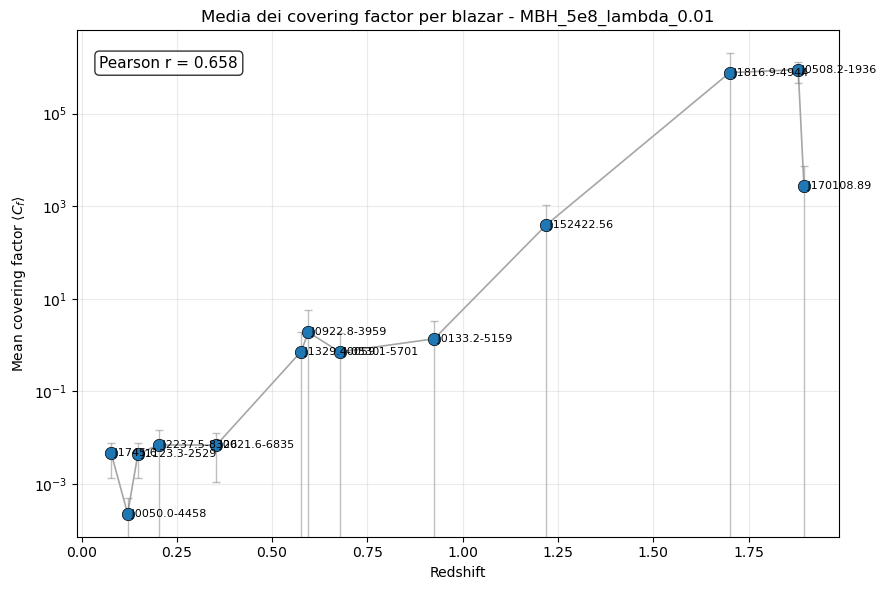

In [72]:
# Media dei covering factor per blazar in uno scenario scelto

scenario_scelto = SCENARI[0]["scenario"]

col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_cf_mean = df_risultati_finali.copy()
df_cf_mean = df_cf_mean[df_cf_mean["scenario"] == scenario_scelto].copy()
df_cf_mean["covering_factor"] = pd.to_numeric(df_cf_mean["covering_factor"], errors="coerce")

df_cf_mean = df_cf_mean[
    df_cf_mean["covering_factor"].notna() &
    (df_cf_mean["covering_factor"] > 0)
].copy()

df_cf_mean_blazar = (
    df_cf_mean
    .groupby("label", as_index=False)
    .agg(
        Cf_mean=("covering_factor", "mean"),
        Cf_std=("covering_factor", "std"),
        N_linee=("covering_factor", "count")
    )
)

df_cf_mean_blazar = df_cf_mean_blazar.merge(
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_cf_mean_blazar["redshift"] = pd.to_numeric(df_cf_mean_blazar["redshift"], errors="coerce")
df_cf_mean_blazar = df_cf_mean_blazar[df_cf_mean_blazar["redshift"].notna()].copy()
df_cf_mean_blazar = df_cf_mean_blazar.sort_values("redshift").reset_index(drop=True)

print(f"Media dei covering factor per blazar - scenario {scenario_scelto}")
display(df_cf_mean_blazar)

if (
    len(df_cf_mean_blazar) >= 2 and
    df_cf_mean_blazar["redshift"].nunique() > 1 and
    df_cf_mean_blazar["Cf_mean"].nunique() > 1
):
    pearson_mean = df_cf_mean_blazar["redshift"].corr(df_cf_mean_blazar["Cf_mean"], method="pearson")
else:
    pearson_mean = np.nan

print(f"Pearson(<Cf>, z) per {scenario_scelto} = {pearson_mean:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    color="gray",
    linewidth=1.2,
    alpha=0.7,
    zorder=1
)

ax.scatter(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    s=80,
    edgecolors="black",
    linewidths=0.5,
    zorder=2
)

for _, row in df_cf_mean_blazar.iterrows():
    ax.text(
        row["redshift"],
        row["Cf_mean"],
        f" {row['label']}",
        fontsize=8,
        va="center",
        ha="left"
    )

# Barre d'errore per la deviazione standard del covering factor
ax.errorbar(
    df_cf_mean_blazar["redshift"],
    df_cf_mean_blazar["Cf_mean"],
    yerr=df_cf_mean_blazar["Cf_std"],
    fmt="none",
    ecolor="gray",
    elinewidth=1,
    alpha=0.5,
    capsize=3,
    zorder=0
)


ax.text(
    0.03, 0.95,
    f"Pearson r = {pearson_mean:.3f}" if pd.notna(pearson_mean) else "Pearson r = nan",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

ax.set_xlabel("Redshift")
ax.set_ylabel(r"Mean covering factor $\langle C_f \rangle$")
ax.set_title(f"Media dei covering factor per blazar - {scenario_scelto}")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

#### Contour con redshift

CONTOUR PLOT: è un modo per rappresentare la densità dei punti in un piano 2D --> invece di vedere solo i punti, si vedono linee di livello che uniscono zone con la stessa densità di punti
Nel mio caso uso KDE= Kernel Density Estimation --> Cosa fa: 1.ogni punto viene “allargato” in una piccola campana, 2.tutte le campane si sommano 2.si formano le curve di livello
A cosa serve : se ci fosse correlazione, si vedrebbero contorni inclinati e struttura allungata 

In [ ]:
# === PREPARAZIONE DATI ===

col_redshift = trova_colonna(
    df_all,
    ["redshift", "z", "Redshift", "Z"],
    obbligatoria=True
)

df_kde = df_risultati_finali.merge(  #unisco il dataframe dei CF con quello dei redshift
    df_all[["label", col_redshift]].rename(columns={col_redshift: "redshift"}),
    on="label",
    how="left"
)

df_kde["covering_factor"] = pd.to_numeric(df_kde["covering_factor"], errors="coerce")
df_kde["redshift"] = pd.to_numeric(df_kde["redshift"], errors="coerce")

df_kde = df_kde[  
    df_kde["covering_factor"].notna() &
    (df_kde["covering_factor"] > 0) &
    df_kde["redshift"].notna()
].copy()

print(f"Punti totali disponibili: {len(df_kde)}")

Punti totali disponibili: 156


In [ ]:
# === COLORI PER LINEA e MARKER PER SCENARIO ===
import seaborn as sns 

ordine_linee = ["CIII", "CIV", "Ha", "Hb", "Hd", "Hg", "MgII"]
linee_presenti = df_kde["line_name"].dropna().unique().tolist()

linee_uniche = [l for l in ordine_linee if l in linee_presenti]
linee_uniche += [l for l in sorted(linee_presenti) if l not in linee_uniche]

palette = sns.color_palette("tab10", len(linee_uniche))
color_map = dict(zip(linee_uniche, palette))

marker_map = {
    "MBH_5e8_lambda_0.01": "o",
    "MBH_5e8_lambda_0.1":  "s",
    "MBH_1e9_lambda_0.01": "^",
    "MBH_1e9_lambda_0.1":  "D",
}

# === REDSHIFT PER BLAZAR ===

df_blazar_z = df_kde[["label", "redshift"]].drop_duplicates().copy()
df_blazar_z = df_blazar_z.sort_values("redshift")

In [ ]:
# =========================
# Funzione di supporto per un singolo grafico
# =========================
def plot_cf_range(df_range, titolo, ylim=None):
    print(f"{titolo}: {len(df_range)} punti")
    plt.figure(figsize=(10, 6))

    # contour
    if len(df_range) >= 3:
        sns.kdeplot( 
            data=df_range, 
            x="redshift",
            y="covering_factor",
            levels=6,
            color="black",
            linewidths=1.2
        )

    # linee e scenari presenti davvero in questo grafico
    linee_presenti = df_range["line_name"].dropna().unique().tolist()
    linee_presenti = [l for l in ordine_linee if l in linee_presenti] + [
        l for l in sorted(linee_presenti) if l not in ordine_linee
    ]
    scenari_presenti = [s for s in marker_map if s in df_range["scenario"].unique()]

    # punti: colore = linea, marker = scenario
    for scenario in scenari_presenti:
        df_tmp = df_range[df_range["scenario"] == scenario].copy()
        if df_tmp.empty:
            continue

        sns.scatterplot( 
            data=df_tmp,
            x="redshift",
            y="covering_factor",
            hue="line_name",
            hue_order=linee_presenti,
            palette={l: color_map[l] for l in linee_presenti},
            marker=marker_map[scenario],
            s=70,
            edgecolor="black",
            linewidth=0.3,
            legend=False
        )

    # limiti asse y
    if ylim is not None:
        plt.ylim(*ylim)

    y_top = plt.ylim()[1]

    # linee verticali + etichette blazar
    for _, row in df_blazar_z.iterrows():
        z = row["redshift"]
        label = row["label"]

        plt.axvline(z, color="gray", alpha=0.15, linewidth=1)
        plt.text(
            z,
            y_top,
            label,
            rotation=90,
            fontsize=7,
            alpha=0.7,
            ha="center",
            va="bottom"
        )

    plt.xlabel("Redshift")
    plt.ylabel("Covering factor")
    plt.title(titolo)
    plt.grid(True, alpha=0.3)

    # legenda linee solo presenti
    legend_linee = [
        Line2D([0], [0],
               marker="o",
               color="w",
               markerfacecolor=color_map[linea],
               markeredgecolor="black",
               markersize=8,
               label=linea)
        for linea in linee_presenti
    ]

    # legenda scenari solo presenti
    legend_scenari = [
        Line2D([0], [0],
               marker=marker_map[scenario],
               color="black",
               linestyle="None",
               markersize=8,
               label=scenario)
        for scenario in scenari_presenti
    ]

    if legend_linee:
        leg1 = plt.legend(
            handles=legend_linee,
            title="Linea",
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )
        plt.gca().add_artist(leg1)

    if legend_scenari:
        plt.legend(
            handles=legend_scenari,
            title="Scenario",
            bbox_to_anchor=(1.02, 0.45),
            loc="upper left"
        )

    plt.tight_layout()
    plt.show()

Covering factor vs redshift - Cf < 1: 126 punti


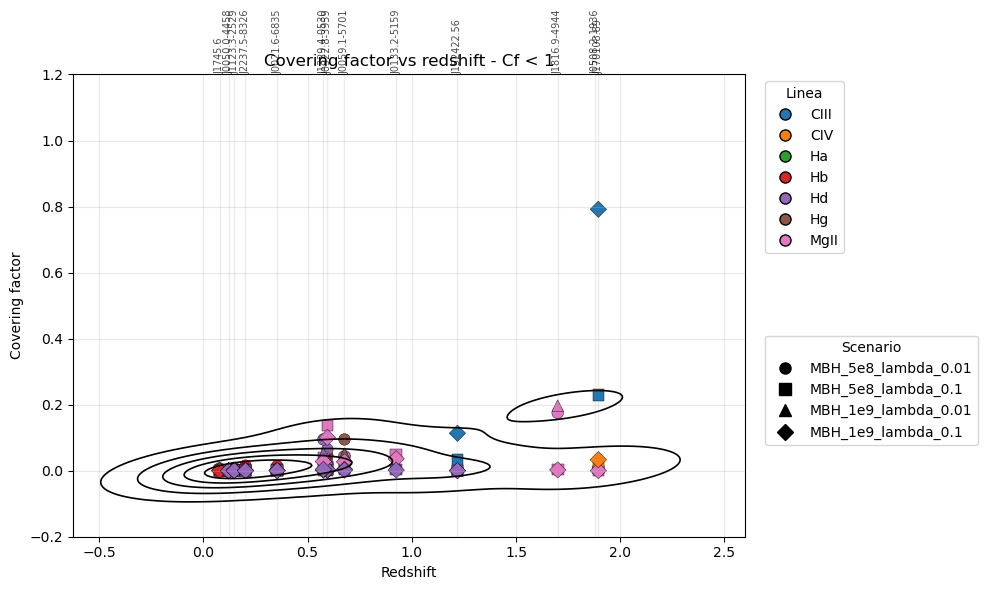

Covering factor vs redshift - 1 < Cf < 100: 13 punti


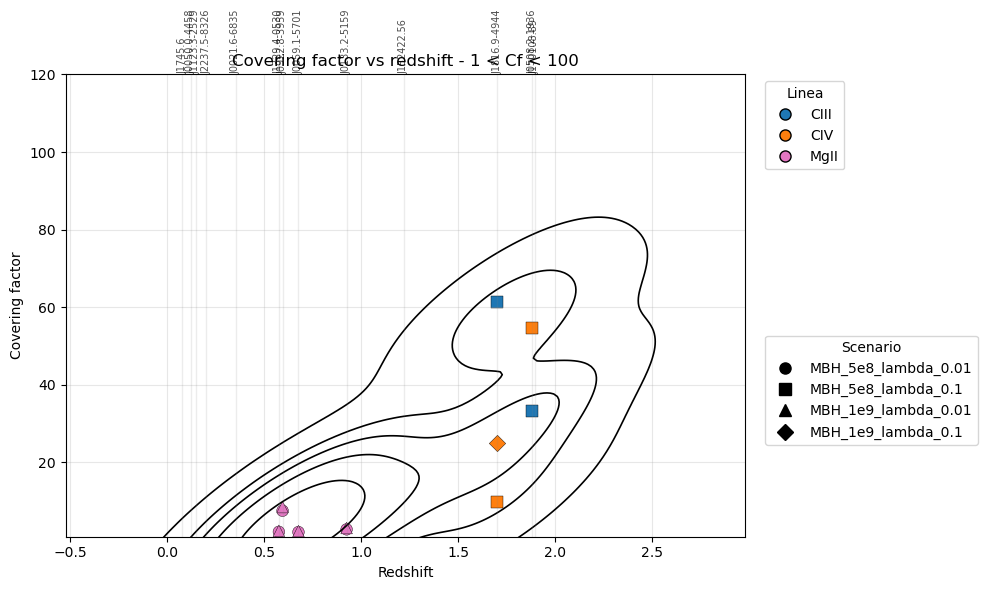

Covering factor vs redshift - Cf > 100: 17 punti


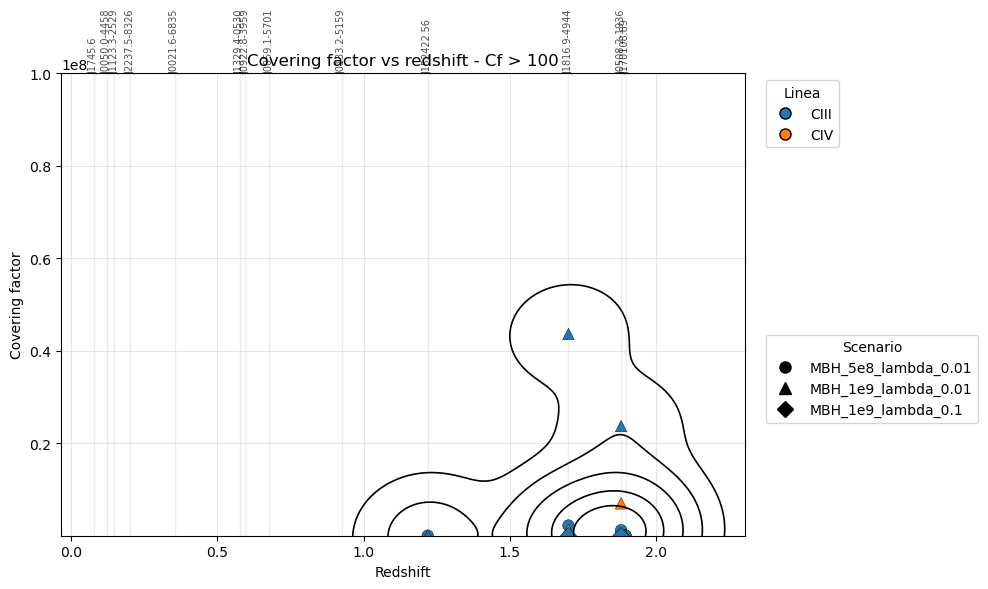

In [ ]:
# =========================
# 1) Cf < 1
# =========================
df_low = df_kde[df_kde["covering_factor"] < 1].copy() #filtro per tenere solo i punti con covering factor < 1
plot_cf_range(
    df_low, #passo il dataframe filtrato
    "Covering factor vs redshift - Cf < 1",
    ylim=(-0.2, 1.2)
)

# =========================
# 2) 1 < Cf < 100
# =========================
df_mid = df_kde[ 
    (df_kde["covering_factor"] > 1) &
    (df_kde["covering_factor"] < 100)
].copy()

plot_cf_range(
    df_mid,
    "Covering factor vs redshift - 1 < Cf < 100",
    ylim=(0.8, 120)
)

# =========================
# 3) Cf > 100
# =========================
df_high = df_kde[df_kde["covering_factor"] > 100].copy()
plot_cf_range(
    df_high,
    "Covering factor vs redshift - Cf > 100",
    ylim=(80, 100000000)
)


In [77]:
# Controllo del numero teorico atteso:numero di righe per scenario e numero totale finale

print("=" * 100)
print("CONTROLLO PER SCENARIO")
print("=" * 100)

for scenario in SCENARI:
    n_scenario = len(df_risultati_finali[df_risultati_finali["scenario"] == scenario["scenario"]])
    print(f"{scenario['scenario']}: {n_scenario} righe")

print(f"\nTotale righe finali: {len(df_risultati_finali)}")
print("=" * 100)

CONTROLLO PER SCENARIO
MBH_5e8_lambda_0.01: 39 righe
MBH_5e8_lambda_0.1: 39 righe
MBH_1e9_lambda_0.01: 39 righe
MBH_1e9_lambda_0.1: 39 righe

Totale righe finali: 156


#### Distribuzione di f nei 4 scenari

/tmp/ipykernel_2391/1593215408.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


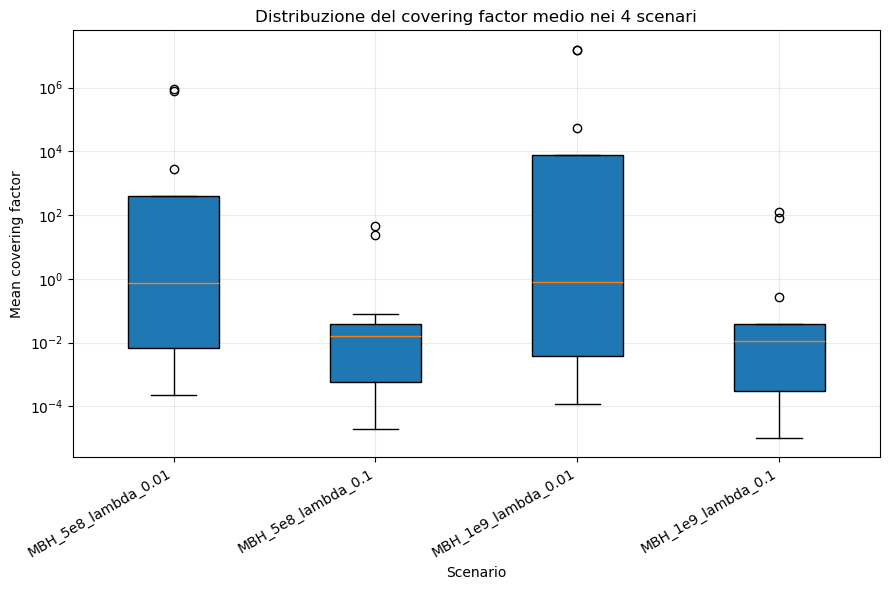

In [78]:
# =========================
# Boxplot del covering factor medio nei 4 scenari
# =========================

# 1. Dati di partenza
df_cf_box = df_risultati_finali.copy()

df_cf_box["covering_factor"] = pd.to_numeric(df_cf_box["covering_factor"], errors="coerce")

df_cf_box = df_cf_box[
    df_cf_box["covering_factor"].notna() &
    (df_cf_box["covering_factor"] > 0)
].copy()

# 2. Media per blazar e scenario
df_cf_mean = (
    df_cf_box
    .groupby(["label", "scenario"], as_index=False)
    .agg(Cf_mean=("covering_factor", "mean"))
)

# 3. Ordine scenari
ordine_scenari = [s["scenario"] for s in SCENARI]

# 4. Costruisco i dati per il boxplot
data_box = [
    df_cf_mean[df_cf_mean["scenario"] == scenario]["Cf_mean"].values
    for scenario in ordine_scenari
]

# %%
# 5. Plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.boxplot(
    data_box,
    labels=ordine_scenari,
    patch_artist=True
)

ax.set_yscale("log")
ax.set_xlabel("Scenario")
ax.set_ylabel("Mean covering factor")
ax.set_title("Distribuzione del covering factor medio nei 4 scenari")

ax.grid(True, which="both", alpha=0.25)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()